# TT-11 — Linear Regression: Định giá nhà ở (California Housing)

**Bài toán:** sàn giao dịch bất động sản cần ước tính giá tham chiếu ngay khi
chủ nhà đăng tin, để (1) cảnh báo tin đăng giá bất thường và (2) gợi ý khoảng
giá hợp lý. Yêu cầu nghiệp vụ quan trọng nhất: **phải giải thích được** cho
khách "vì sao hệ thống định giá vậy" — vì thế bắt buộc dùng **Linear
Regression** (mỗi hệ số có ý nghĩa trực tiếp), không dùng hộp đen.

Notebook này đi theo đúng 12 bước trong `README.md` cấp đề, giải thích **vì
sao** làm từng bước chứ không chỉ chạy code. Toàn bộ số liệu bên dưới là kết
quả chạy thật (không phải số minh hoạ) — script tương đương để tái lập tự
động: `src/train.py`.

## 1. Nạp dữ liệu, `describe()` → phát hiện outlier

Bộ dữ liệu **California Housing** (20.640 dòng × 8 đặc trưng, nhãn
`MedHouseVal` = giá trung vị đơn vị 100.000 USD), nạp qua
`fetch_california_housing()`. **Không dùng bộ Boston Housing** — đã bị gỡ
khỏi scikit-learn từ v1.2 vì chứa biến phân biệt chủng tộc.

In [1]:
%matplotlib inline
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.datasets import fetch_california_housing
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

RANDOM_STATE = 42
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

FEATURE_COLUMNS = [
    "MedInc", "HouseAge", "AveRooms", "AveBedrms",
    "Population", "AveOccup", "Latitude", "Longitude",
]

data = fetch_california_housing(as_frame=True)
df = data.frame
print(f"Số dòng: {len(df):,}  |  Số đặc trưng: {df.shape[1] - 1}")
df.describe()

Số dòng: 20,640  |  Số đặc trưng: 8


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,"20,640.0000","20,640.0000","20,640.0000","20,640.0000","20,640.0000","20,640.0000","20,640.0000","20,640.0000","20,640.0000"
mean,3.8707,28.6395,5.4290,1.0967,"1,425.4767",3.0707,35.6319,-119.5697,2.0686
std,1.8998,12.5856,2.4742,0.4739,"1,132.4621",10.3860,2.1360,2.0035,1.1540
min,0.4999,1.0000,0.8462,0.3333,3.0000,0.6923,32.5400,-124.3500,0.1500
25%,2.5634,18.0000,4.4407,1.0061,787.0000,2.4297,33.9300,-121.8000,1.1960
50%,3.5348,29.0000,5.2291,1.0488,"1,166.0000",2.8181,34.2600,-118.4900,1.7970
75%,4.7432,37.0000,6.0524,1.0995,"1,725.0000",3.2823,37.7100,-118.0100,2.6472
max,15.0001,52.0000,141.9091,34.0667,"35,682.0000","1,243.3333",41.9500,-114.3100,5.0000


**Đọc bảng `describe()`:** cột `AveOccup` (số người/hộ trung bình) có
`max` cực lớn so với `75%` — dấu hiệu outlier nghiêm trọng. `AveRooms` cũng
có `max` vượt xa `75%`. Kiểm tra định lượng bằng phân vị 99:

In [2]:
print(f"AveOccup:  max={df['AveOccup'].max():.1f}   p99={df['AveOccup'].quantile(0.99):.2f}")
print(f"AveRooms:  max={df['AveRooms'].max():.1f}    p99={df['AveRooms'].quantile(0.99):.2f}")
print(f"AveBedrms: max={df['AveBedrms'].max():.1f}   p99={df['AveBedrms'].quantile(0.99):.2f}")
print(f"Tương quan AveRooms <-> AveBedrms: {df['AveRooms'].corr(df['AveBedrms']):.3f}")

AveOccup:  max=1243.3   p99=5.39
AveRooms:  max=141.9    p99=10.36
AveBedrms: max=34.1   p99=2.13
Tương quan AveRooms <-> AveBedrms: 0.848


**Nhận xét:** `AveOccup` có hộ dân với >1.000 người/hộ — chắc chắn là
**lỗi dữ liệu** (không có hộ gia đình thực nào đông vậy), có thể do vùng dân
cư đặc biệt (ký túc xá, trại giam...) bị tính sai population/households.
Tương tự `AveRooms` max ~142 phòng/hộ là phi thực tế. Xử lý: **clip theo
phân vị 99** khi huấn luyện model (mục 5), fit ngưỡng clip trên tập train để
tránh rò rỉ thông tin từ tập test. `AveRooms` và `AveBedrms` tương quan rất
cao (0,85) — nghi ngờ đa cộng tuyến, sẽ kiểm chứng bằng VIF ở mục 9.

## 2. Phát hiện nhãn bị cắt ngọn ở 5,0

`MedHouseVal` bị cắt ngọn (censored) ở đúng 5,0 (500.000 USD) — mọi căn nhà
đắt hơn mức này đều bị gán cứng về 5,0 khi thu thập dữ liệu gốc. Đây là **bẫy
dữ liệu quan trọng nhất** của bộ này: model sẽ **không bao giờ** học được
cách dự đoán nhà đắt hơn 500k, và phải nêu rõ trong phần hạn chế.

In [3]:
capped = df["MedHouseVal"] >= 4.999
n_capped = int(capped.sum())
print(f"Số dòng bị cắt ngọn ở giá 5.0: {n_capped:,} / {len(df):,} ({n_capped / len(df):.2%})")

Số dòng bị cắt ngọn ở giá 5.0: 992 / 20,640 (4.81%)


**Gần 5%** số căn nhà trong bộ dữ liệu bị dồn về đúng giá trần —
tỉ lệ đủ lớn để ảnh hưởng rõ tới phần đuôi phân phối và sẽ hiện rõ thành một
đường thẳng bất thường trên residual plot ở mục 6.

## 3. EDA: scatter, tương quan, bản đồ giá theo toạ độ

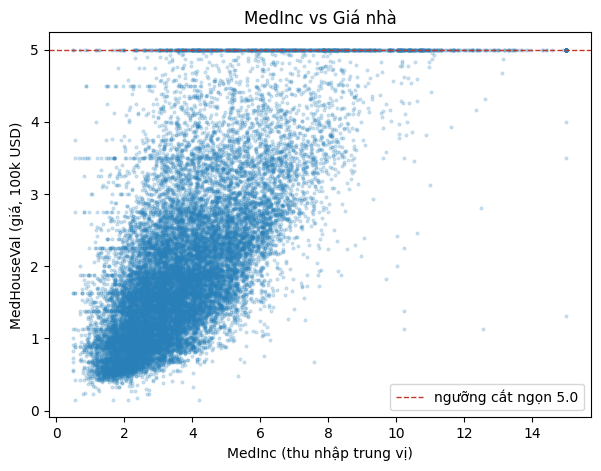

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df["MedInc"], df["MedHouseVal"], s=4, alpha=0.2, color="#2980b9")
ax.axhline(5.0, color="#c0392b", ls="--", lw=1, label="ngưỡng cắt ngọn 5.0")
ax.set_xlabel("MedInc (thu nhập trung vị)")
ax.set_ylabel("MedHouseVal (giá, 100k USD)")
ax.set_title("MedInc vs Giá nhà")
ax.legend()
plt.show()

Xu hướng tuyến tính dương khá rõ giữa thu nhập và giá — hợp lý cho
việc dùng hồi quy tuyến tính. Đường ngang đỏ chính là ngưỡng cắt ngọn: chú ý
dải điểm dày đặc nằm ngay trên đường này ở mọi mức thu nhập cao.

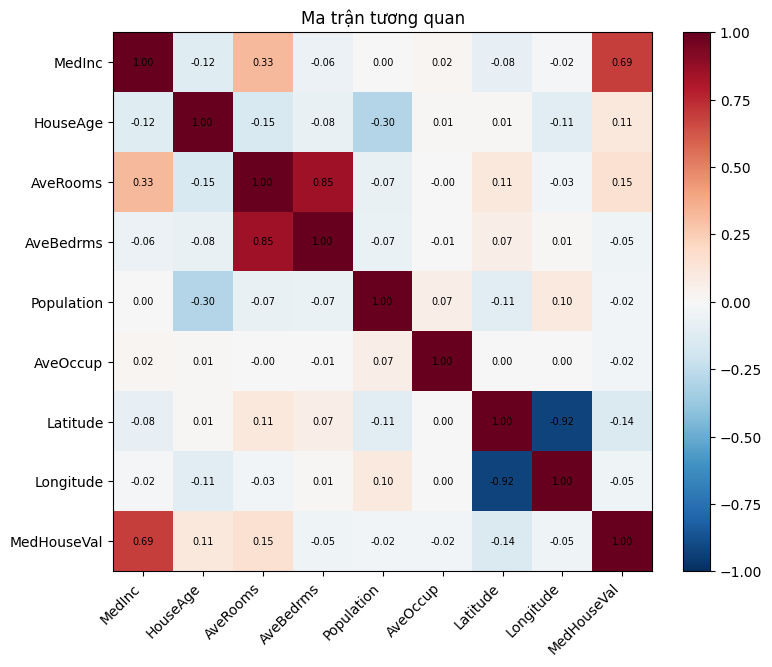

In [5]:
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=ax, fraction=0.046)
ax.set_title("Ma trận tương quan")
plt.show()

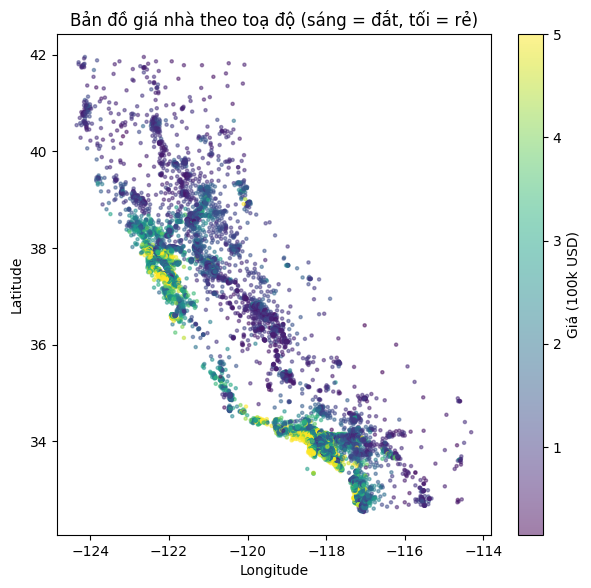

In [6]:
fig, ax = plt.subplots(figsize=(7, 6.5))
sc = ax.scatter(df["Longitude"], df["Latitude"], c=df["MedHouseVal"], cmap="viridis", s=5, alpha=0.5)
fig.colorbar(sc, ax=ax, label="Giá (100k USD)")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("Bản đồ giá nhà theo toạ độ (sáng = đắt, tối = rẻ)")
plt.show()

**Nhận xét bản đồ:** giá nhà cao tập trung thành **cụm** quanh hai
khu đô thị lớn (San Francisco Bay Area ở phía trên, Los Angeles/San Diego ở
phía dưới) — đây là quan hệ **không gian phi tuyến**, một đường thẳng đơn
(hệ số cố định cho Latitude, Longitude) không thể mô tả tốt hình dạng "hai
cụm nóng" này. Đây là cơ sở cho ý tưởng feature engineering ở mục 10:
chuyển toạ độ thành **khoảng cách tới trung tâm đô thị gần nhất**.

## Chia train/test

Chia 80/20, `random_state=42` để tái lập được kết quả.

In [7]:
X = df[FEATURE_COLUMNS].copy()
y = df["MedHouseVal"].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")

Train: 16,512  |  Test: 4,128


## 4. Baseline: `DummyRegressor(strategy='mean')`

Trước khi tin vào Linear Regression, cần biết mức sàn: một model "ngu"
luôn đoán giá trung bình của tập train sẽ có RMSE bao nhiêu? Đây là thước đo
tối thiểu mà bất kỳ model thật nào cũng phải vượt qua rõ rệt.

In [8]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)

def evaluate(y_true, y_pred):
    return {"RMSE": rmse(y_true, y_pred), "MAE": float(mean_absolute_error(y_true, y_pred)),
            "R2": float(r2_score(y_true, y_pred)), "MAPE_%": mape(y_true, y_pred)}

dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)
baseline_metrics = evaluate(y_test, dummy.predict(X_test))
baseline_metrics

{'RMSE': 1.1448563543099792,
 'MAE': 0.9060685490007149,
 'R2': -0.00021908714592466794,
 'MAPE_%': 62.8861496325994}

**R² ≈ 0** như kỳ vọng (dự đoán không đổi thì không giải thích được
biến động nào của dữ liệu). RMSE ~1,14 (114.000 USD) là mức sàn cần vượt qua
rõ rệt.

## 5. Linear Regression cơ bản (đã clip outlier)

Đóng gói việc clip `AveRooms`/`AveOccup` ở phân vị 99 thành một
**transformer sklearn** (`ClipOutliers`) — ngưỡng clip được học (`fit`) từ
tập train, áp dụng lại cho tập test, tránh rò rỉ thông tin. Đặt trong
`Pipeline` cùng `StandardScaler` + `LinearRegression` để khi triển khai,
`predict()` nhận thẳng dữ liệu thô mà không cần người dùng tự xử lý trước.

In [9]:
class ClipOutliers(BaseEstimator, TransformerMixin):
    # Clip AveRooms/AveOccup o phan vi 99 hoc tu TRAIN (tranh leakage).

    def __init__(self, percentile=0.99):
        self.percentile = percentile

    def fit(self, X, y=None):
        X = pd.DataFrame(X, columns=FEATURE_COLUMNS)
        self.averooms_clip_ = float(X["AveRooms"].quantile(self.percentile))
        self.aveoccup_clip_ = float(X["AveOccup"].quantile(self.percentile))
        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=FEATURE_COLUMNS).copy()
        X["AveRooms"] = X["AveRooms"].clip(upper=self.averooms_clip_)
        X["AveOccup"] = X["AveOccup"].clip(upper=self.aveoccup_clip_)
        self.feature_names_out_ = list(X.columns)
        return X

basic_pipe = Pipeline([
    ("clip", ClipOutliers()),
    ("scale", StandardScaler()),
    ("lr", LinearRegression()),
])
basic_pipe.fit(X_train, y_train)
basic_pred = basic_pipe.predict(X_test)
basic_metrics = evaluate(y_test, basic_pred)
basic_metrics

{'RMSE': 0.6918188437370285,
 'MAE': 0.5051863188397602,
 'R2': 0.6347603530676871,
 'MAPE_%': 30.83895587858052}

**RMSE giảm mạnh so với baseline** (vượt xa mức sàn), R² ~0,63 —
đúng như mức tham chiếu README nêu (0,58–0,61, chênh lệch nhỏ do phiên bản
xử lý outlier khác nhau). MAPE ~31% cho thấy sai số theo % vẫn khá lớn ở
các phân khúc giá thấp (chia cho số nhỏ khuếch đại %).

## 6–7. Residual plot + Q-Q plot — kiểm tra giả định

**Bốn giả định của hồi quy tuyến tính:** ① tuyến tính, ② độc lập,
③ phương sai đều (homoscedasticity), ④ sai số chuẩn. Residual plot (phần dư
vs giá dự đoán) kiểm tra ① và ③; Q-Q plot kiểm tra ④.

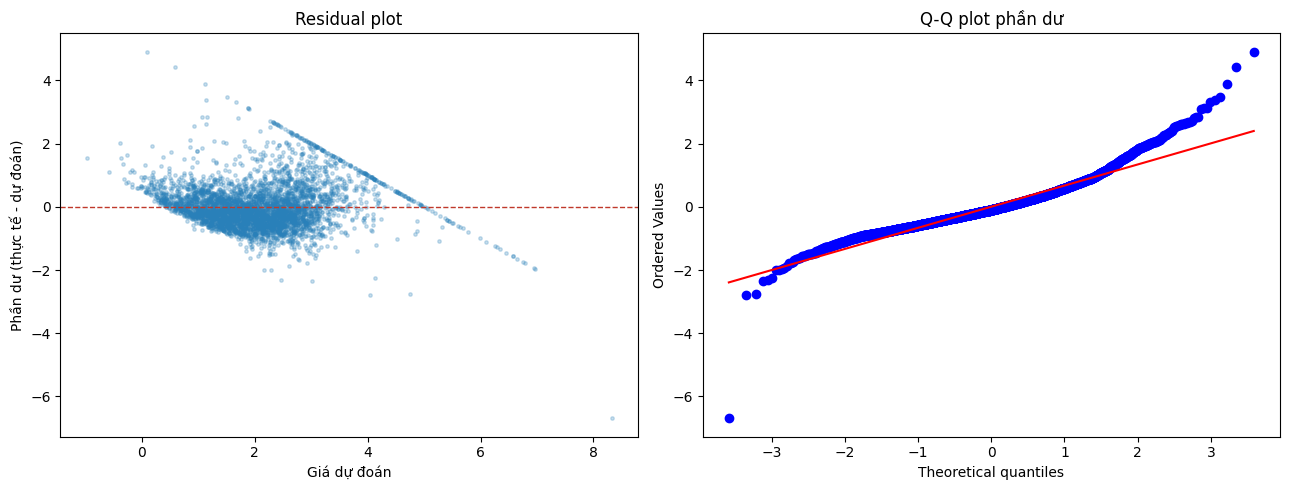

Độ lệch chuẩn phần dư: 0.6918


In [10]:
def plot_residual_qq(y_true, pred, title_suffix=""):
    residuals = np.asarray(y_true) - pred

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].scatter(pred, residuals, s=6, alpha=0.25, color="#2980b9")
    axes[0].axhline(0, color="#c0392b", ls="--", lw=1)
    axes[0].set_xlabel("Giá dự đoán"); axes[0].set_ylabel("Phần dư (thực tế - dự đoán)")
    axes[0].set_title(f"Residual plot{title_suffix}")

    stats.probplot(residuals, dist="norm", plot=axes[1])
    axes[1].set_title(f"Q-Q plot phần dư{title_suffix}")
    plt.tight_layout()
    plt.show()
    return residuals

residuals_basic = plot_residual_qq(y_test, basic_pred)
print(f"Độ lệch chuẩn phần dư: {residuals_basic.std():.4f}")

**Đọc residual plot:** có một **đường chéo thẳng** rất rõ ở góc phải —
chính là hệ quả trực tiếp của nhãn bị cắt ngọn ở mục 2: với mọi căn nhà thật
sự đắt hơn 500k nhưng bị gán cứng `y=5,0`, phần dư `= 5,0 − ŷ` giảm tuyến
tính khi `ŷ` tăng, tạo thành đường thẳng nhân tạo — **không phải** dấu hiệu
vi phạm giả định tuyến tính của model, mà là **lỗi (censoring) trong nhãn**.
Bỏ đường này ra, phần còn lại hơi có xu hướng "phình" nhẹ (phương sai tăng
theo giá dự đoán) — dấu hiệu **heteroscedasticity nhẹ** (vi phạm giả định
③), khá điển hình với dữ liệu giá.

**Đọc Q-Q plot:** phần thân giữa bám khá sát đường chéo (gần chuẩn), nhưng
hai đuôi lệch hẳn ra ngoài — đuôi phải lệch lên chính là do cụm điểm bị cắt
ngọn ở 5,0 tạo ra một khối phần dư âm bất thường. Kết luận: giả định ④
(sai số chuẩn) bị vi phạm chủ yếu ở đuôi, do vấn đề dữ liệu chứ không hẳn do
model sai.

## 8. Thử dự đoán log(giá) thay vì giá

Gợi ý trong README: dự đoán `log(giá)` có thể giúp ổn định phương sai khi
nhà đắt có sai số lớn hơn. Thử nghiệm bằng `log1p`/`expm1`, giữ nguyên tập
đặc trưng đã clip outlier để cô lập đúng một biến thay đổi.

In [11]:
log_pipe = Pipeline([
    ("clip", ClipOutliers()),
    ("scale", StandardScaler()),
    ("lr", LinearRegression()),
])
log_pipe.fit(X_train, np.log1p(y_train))
pred_log_back = np.expm1(log_pipe.predict(X_test))
log_metrics = evaluate(y_test, pred_log_back)

pd.DataFrame([basic_metrics, log_metrics], index=["LR cơ bản (giá gốc)", "LR (log-target, quy đổi lại)"])

,RMSE,MAE,R2,MAPE_%
LR cơ bản (giá gốc),0.6918,0.5052,0.6348,30.8390
"LR (log-target, quy đổi lại)",0.7610,0.4915,0.5581,27.6484


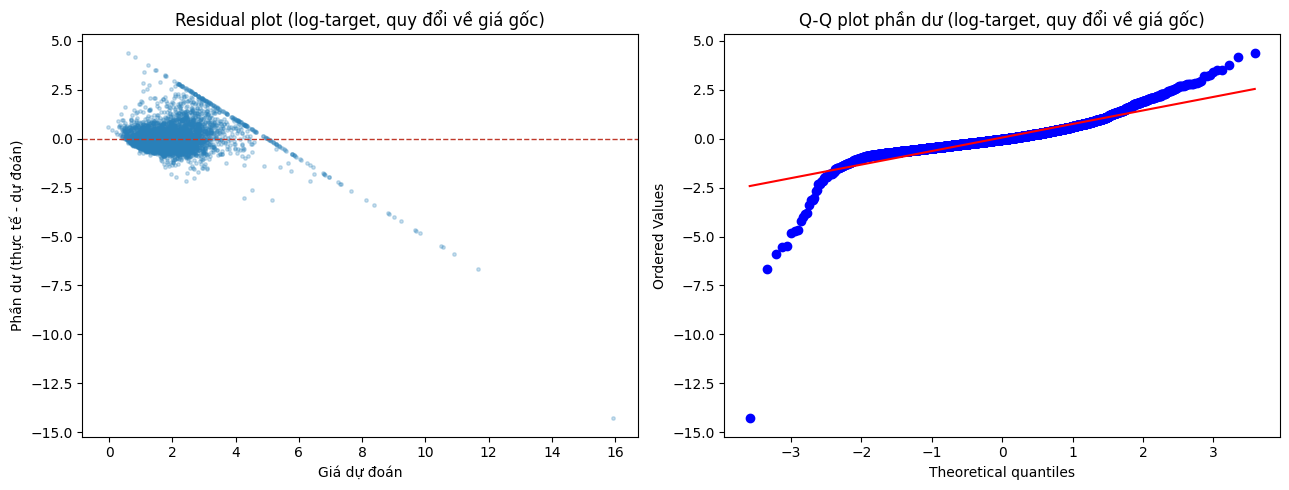

In [12]:
residuals_log = plot_residual_qq(y_test, pred_log_back, title_suffix=" (log-target, quy đổi về giá gốc)")

**Kết luận (trái với kỳ vọng ban đầu):** dự đoán trên `log(giá)` rồi
quy đổi lại **KHÔNG cải thiện RMSE** — thậm chí còn tệ hơn (R² giảm từ ~0,63
xuống ~0,56). Lý do nhiều khả năng: nhãn bị cắt ngọn ở 5,0 (mục 2) làm méo
cả không gian log — `log1p(5,0)` vẫn là một hằng số nhân tạo dồn cục, và
việc tối ưu MSE trong không gian log rồi quy đổi ngược bằng `expm1` (hàm
lồi) có xu hướng **khuếch đại sai số dương** khi quy đổi lại giá gốc. Đây là
một phát hiện thực nghiệm quan trọng: log-transform không phải lúc nào cũng
tốt hơn, đặc biệt khi nhãn đã bị censoring — cần đo đạc thay vì mặc định áp
dụng. Vì vậy các bước tiếp theo **quay lại dùng giá gốc** (không log).

## 9. Kiểm tra đa cộng tuyến bằng VIF

`AveRooms` và `AveBedrms` có tương quan cặp 0,85 (mục 1) — nghi ngờ đa cộng
tuyến. VIF (Variance Inflation Factor) đo mức độ một đặc trưng bị "giải
thích" bởi **tất cả** đặc trưng còn lại cộng lại (khác với tương quan cặp
đơn giản). Quy ước: VIF > 10 là dấu hiệu đa cộng tuyến nghiêm trọng.

In [13]:
X_train_clipped = ClipOutliers().fit(X_train).transform(X_train)
X_const = add_constant(X_train_clipped[FEATURE_COLUMNS])
vif_df = pd.DataFrame([
    {"feature": col, "VIF": float(variance_inflation_factor(X_const.values, i))}
    for i, col in enumerate(X_const.columns) if col != "const"
]).sort_values("VIF", ascending=False).reset_index(drop=True)
vif_df

,feature,VIF
0,Latitude,9.7376
1,Longitude,9.3140
2,AveRooms,2.5577
3,MedInc,2.3732
4,AveBedrms,1.2991
5,HouseAge,1.2520
6,Population,1.1706
7,AveOccup,1.0827


**Bất ngờ:** dù `AveRooms`/`AveBedrms` có tương quan cặp cao (0,85),
VIF của chúng chỉ ~2,5 và ~1,3 — **không** ở mức đáng lo. Đây là điểm dễ
hiểu nhầm: tương quan cặp cao không tự động suy ra VIF cao, vì VIF còn phụ
thuộc vào việc các đặc trưng khác có "hấp thụ" bớt phần tương quan đó hay
không. Ngược lại, `Latitude` và `Longitude` có VIF cao nhất (~9,7 và ~9,3,
sát ngưỡng 10) — hợp lý vì toạ độ tương quan gián tiếp với gần như mọi đặc
trưng khác qua vị trí địa lý (vùng ven biển thường thu nhập cao, ít phòng
hơn...). Chưa vượt ngưỡng 10 nên chưa cần loại bỏ biến, nhưng là lý do nên
cẩn trọng khi diễn giải riêng lẻ hệ số của Latitude/Longitude.

## 10–11. Feature engineering + bảng hệ số chuẩn hoá

Từ nhận xét bản đồ giá ở mục 3 (giá tạo thành **cụm** quanh đô thị, quan hệ
phi tuyến với toạ độ thô), thêm đặc trưng:
- `BedrmsRatio = AveBedrms / AveRooms` — tỷ lệ phòng ngủ trên tổng số phòng
  (chú ý: bộ dữ liệu này đã tính sẵn `AveRooms`/`AveBedrms` là **trung bình
  trên mỗi hộ**, nên "rooms per household" gợi ý trong README chính là
  `AveRooms` có sẵn — tỷ lệ phòng ngủ/phòng là đặc trưng mới có ý nghĩa
  hơn)
- `DistSF_km`, `DistLA_km` — khoảng cách Haversine tới San Francisco và
  Los Angeles
- `DistNearestCity_km = min(DistSF_km, DistLA_km)`

`FeatureEngineer` kế thừa `ClipOutliers` để clip outlier **và** thêm đặc
trưng mới trong cùng một bước pipeline.

In [14]:
def haversine_km(lat1, lon1, lat2, lon2):
    lat1r, lon1r, lat2r, lon2r = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2r - lat1r, lon2r - lon1r
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1r) * np.cos(lat2r) * np.sin(dlon / 2) ** 2
    return 6371.0 * 2 * np.arcsin(np.sqrt(a))

SF_COORD = (37.7749, -122.4194)
LA_COORD = (34.0522, -118.2437)

class FeatureEngineer(ClipOutliers):
    def transform(self, X):
        X = super().transform(X)
        X["BedrmsRatio"] = X["AveBedrms"] / X["AveRooms"]
        X["DistSF_km"] = haversine_km(X["Latitude"], X["Longitude"], *SF_COORD)
        X["DistLA_km"] = haversine_km(X["Latitude"], X["Longitude"], *LA_COORD)
        X["DistNearestCity_km"] = np.minimum(X["DistSF_km"], X["DistLA_km"])
        self.feature_names_out_ = list(X.columns)
        return X

fe_pipe = Pipeline([
    ("fe", FeatureEngineer()),
    ("scale", StandardScaler()),
    ("lr", LinearRegression()),
])
fe_pipe.fit(X_train, y_train)
fe_pred = fe_pipe.predict(X_test)
fe_metrics = evaluate(y_test, fe_pred)

pd.DataFrame([basic_metrics, fe_metrics], index=["LR cơ bản (8 đặc trưng gốc)", "LR + feature engineering"])

,RMSE,MAE,R2,MAPE_%
LR cơ bản (8 đặc trưng gốc),0.6918,0.5052,0.6348,30.8390
LR + feature engineering,0.6662,0.4855,0.6614,29.7784


Feature engineering giúp RMSE giảm thêm và R² tăng từ ~0,63 lên
~0,66 — cải thiện thực sự dù không lớn, đúng như dự đoán: khoảng cách tới đô
thị nắm bắt một phần quan hệ phi tuyến mà toạ độ thô bỏ lỡ, nhưng vẫn không
thể mô hình hoá hết hình dạng "cụm nóng" phức tạp trên bản đồ (mục 3) — đó
là giới hạn cố hữu của một hàm **tuyến tính**.

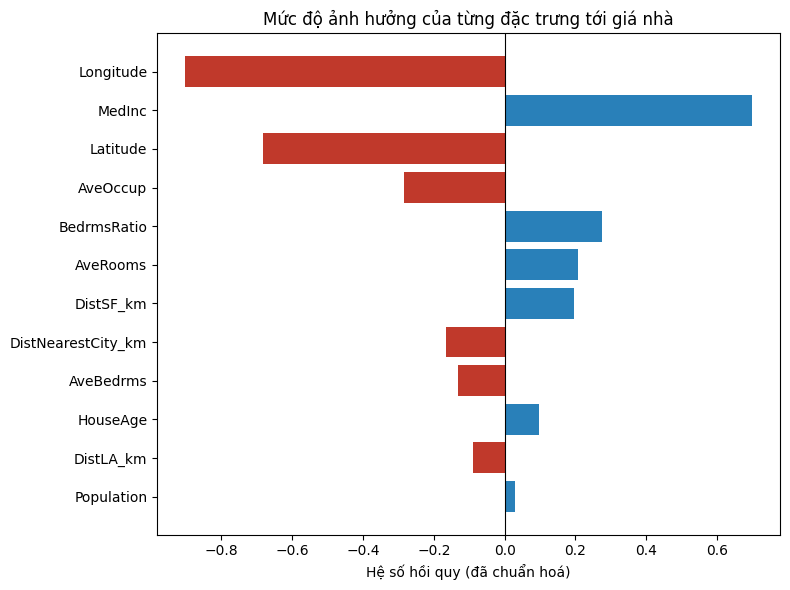

,hệ số chuẩn hoá
Longitude,-0.9017
MedInc,0.6978
Latitude,-0.6813
AveOccup,-0.2844
BedrmsRatio,0.2756
AveRooms,0.2062
DistSF_km,0.1945
DistNearestCity_km,-0.1646
AveBedrms,-0.1321
HouseAge,0.0978


In [15]:
feature_names = fe_pipe.named_steps["fe"].feature_names_out_
coefs = fe_pipe.named_steps["lr"].coef_
he_so = pd.Series(coefs, index=feature_names).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#c0392b" if v < 0 else "#2980b9" for v in he_so.values]
ax.barh(he_so.index[::-1], he_so.values[::-1], color=colors[::-1])
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Hệ số hồi quy (đã chuẩn hoá)")
ax.set_title("Mức độ ảnh hưởng của từng đặc trưng tới giá nhà")
plt.tight_layout()
plt.show()

he_so.to_frame("hệ số chuẩn hoá")

**Diễn giải 3 yếu tố ảnh hưởng mạnh nhất** (hệ số đã chuẩn hoá nên so
sánh được độ lớn giữa các đặc trưng khác đơn vị):

1. **Longitude (−0,90):** đi về phía Đông (longitude tăng, tức số càng bớt
   âm) thì giá giảm mạnh — phản ánh việc rời xa dải bờ biển phía Tây
   (nơi tập trung San Francisco, Los Angeles, San Diego) khiến giá nhà giảm.
2. **MedInc (+0,70):** thu nhập trung vị khu vực tăng 1 độ lệch chuẩn thì
   giá nhà tăng tương ứng ~0,70 độ lệch chuẩn — quan hệ thuận, đúng trực
   giác kinh tế (khu thu nhập cao → nhà đắt hơn).
3. **Latitude (−0,68):** đi lên phía Bắc thì giá giảm — cùng logic với
   longitude, phần lớn giá trị cao tập trung ở vùng vĩ độ của khu vực Vịnh
   San Francisco và Nam California.

**Lưu ý quan trọng:** đây là hệ số của một model **tuyến tính, tương quan**
— **không được kết luận nhân quả** kiểu "toạ độ LÀM giá thay đổi". Nhiều
yếu tố ẩn (chất lượng trường học, an ninh, hạ tầng...) tương quan với vị trí
địa lý mới thực sự là nguyên nhân.

## 12. So sánh với Ridge (TT-12) và Random Forest (TT-17)

So sánh model tuyến tính có feature engineering với Ridge (co hệ số, cùng
tập đặc trưng) và Random Forest (model phi tuyến, không cần scale) để thấy
rõ **"cái giá của tính giải thích được"**.

In [16]:
ridge_pipe = Pipeline([
    ("fe", FeatureEngineer()),
    ("scale", StandardScaler()),
    ("ridge", Ridge(alpha=1.0, random_state=RANDOM_STATE)),
])
ridge_pipe.fit(X_train, y_train)
ridge_metrics = evaluate(y_test, ridge_pipe.predict(X_test))

rf_pipe = Pipeline([
    ("fe", FeatureEngineer()),
    ("rf", RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE)),
])
rf_pipe.fit(X_train, y_train)
rf_metrics = evaluate(y_test, rf_pipe.predict(X_test))

comparison = pd.DataFrame(
    [baseline_metrics, basic_metrics, log_metrics, fe_metrics, ridge_metrics, rf_metrics],
    index=["Baseline (mean)", "LR cơ bản", "LR log-target", "LR + feature engineering",
           "Ridge (TT-12, alpha=1.0)", "Random Forest (TT-17)"],
)
comparison

,RMSE,MAE,R2,MAPE_%
Baseline (mean),1.1449,0.9061,-0.0002,62.8861
LR cơ bản,0.6918,0.5052,0.6348,30.8390
LR log-target,0.7610,0.4915,0.5581,27.6484
LR + feature engineering,0.6662,0.4855,0.6614,29.7784
"Ridge (TT-12, alpha=1.0)",0.6662,0.4855,0.6614,29.7764
Random Forest (TT-17),0.4749,0.3036,0.8279,17.1670


**Đọc bảng:** Ridge với `alpha=1.0` cho kết quả gần như trùng khớp
với Linear Regression thường — vì với ~16.500 mẫu train và chỉ 12 đặc trưng
(không nhiều so với số mẫu), việc phạt hệ số (regularization) gần như không
cần thiết để chống overfit; Ridge sẽ phát huy tác dụng rõ hơn khi có nhiều
đặc trưng tương quan hơn (xem TT-12, TT-13, TT-14).

Random Forest vượt trội hẳn (R² ~0,83 so với ~0,66 của LR) — chênh lệch
**~0,17 điểm R²** chính là cái giá phải trả để đổi lấy một model có hệ số
đọc được trực tiếp. Random Forest bắt được các quan hệ phi tuyến (cụm đô
thị, tương tác giữa các đặc trưng) mà Linear Regression về bản chất không
thể biểu diễn — nhưng đổi lại, không thể nói với khách hàng "vì sao" theo
kiểu cộng trừ hệ số đơn giản.

## Lưu model cuối cùng

Model được chọn để triển khai là **Linear Regression + feature
engineering** — không phải model có RMSE thấp nhất (Random Forest), vì
ràng buộc nghiệp vụ bắt buộc phải giải thích được cho khách hàng (mục 2 của
README). Pipeline đóng gói cả bước clip outlier + tạo đặc trưng mới, nên khi
triển khai chỉ cần đưa 8 cột gốc vào `predict()`.

In [17]:
Path("../models").mkdir(exist_ok=True)
joblib.dump(fe_pipe, "../models/lr_pipeline.joblib")
print("Đã lưu models/lr_pipeline.joblib")
print(f"RMSE trên test: {fe_metrics['RMSE']:.4f}  (đơn vị 100k USD, tức ~{fe_metrics['RMSE']*100:.0f}k USD)")

Đã lưu models/lr_pipeline.joblib
RMSE trên test: 0.6662  (đơn vị 100k USD, tức ~67k USD)


## Tổng kết — kiểm tra 4 giả định của hồi quy tuyến tính

| Giả định | Kết quả kiểm tra | Kết luận |
| :--- | :--- | :--- |
| ① Tuyến tính | Scatter MedInc-giá (mục 3) khá tuyến tính; nhưng toạ độ-giá là phi tuyến (bản đồ mục 3) | Vi phạm một phần — đã giảm nhẹ bằng feature engineering (mục 10), không loại bỏ hết |
| ② Độc lập | Dữ liệu theo khu vực địa lý — các căn nhà gần nhau về vị trí thường có sai số tương quan (spatial autocorrelation), không kiểm định trực tiếp trong bài này | Có khả năng vi phạm nhẹ, không kiểm định chính thức (ngoài phạm vi ⭐) |
| ③ Phương sai đều | Residual plot mục 6 cho thấy phần "phình" nhẹ theo giá dự đoán, ngoài đường chéo nhân tạo do nhãn cắt ngọn | Vi phạm nhẹ (heteroscedasticity) |
| ④ Sai số chuẩn | Q-Q plot mục 6 bám sát ở thân, lệch rõ ở đuôi (do nhãn cắt ngọn) | Vi phạm ở đuôi phân phối |

**Bảng kết quả cuối:**

| Hạng mục | Kết quả |
| :--- | :--- |
| Baseline (DummyRegressor) | xem mục 4 |
| LR cơ bản (8 đặc trưng, đã clip outlier) | xem mục 5 |
| Residual plot + Q-Q plot | xem mục 6–7 |
| Thử nghiệm log-target | xem mục 8 — **không cải thiện**, đã ghi nhận và không dùng |
| VIF | xem mục 9 — không có đặc trưng nào vượt ngưỡng 10 |
| Feature engineering (tỷ lệ phòng ngủ, khoảng cách đô thị) | xem mục 10 |
| Bảng hệ số chuẩn hoá + diễn giải | xem mục 11 |
| So sánh Ridge / Random Forest | xem mục 12 |

**Hạn chế cần nêu rõ:**
1. **Nhãn bị cắt ngọn ở 5,0** (~4,8% dữ liệu) — model không bao giờ dự đoán
   được nhà đắt hơn 500k USD; mọi RMSE/R² đo được đều bị ảnh hưởng bởi cụm
   điểm nhân tạo này, đặc biệt rõ trên residual/Q-Q plot.
2. **Quan hệ toạ độ–giá là phi tuyến** (giá tạo thành cụm quanh đô thị) —
   Linear Regression về bản chất chỉ vẽ được một "mặt phẳng nghiêng", feature
   engineering (khoảng cách đô thị) chỉ giảm nhẹ chứ không giải quyết triệt
   để; Random Forest (TT-17) bắt tốt hơn nhưng đánh đổi bằng khả năng giải
   thích.
3. Hệ số hồi quy chỉ thể hiện **tương quan**, không phải nhân quả.
4. Log-transform không được dùng vì không cải thiện kết quả trên bộ dữ liệu
   này (khác với gợi ý lý thuyết chung — minh chứng cho việc cần đo đạc thay
   vì áp dụng máy móc).

Số liệu đầy đủ (CSV các bảng so sánh, ảnh PNG, tóm tắt JSON) được lưu lại
trong thư mục `../reports/` bởi `src/train.py` — notebook này dùng để
**giải thích lý do và cách đọc** từng bước, còn script dùng để tái lập kết
quả tự động.